# Naive Bayes for Healthcare: what happens under the hood
Bernoulli Naive Bayes on an opioid use disorder (OUD) cohort, explained for clinicians

In the dataset and in the code, the target column is called `OD`: `OD = 1` means an OUD diagnosis was recorded. We keep that short label throughout so the text matches the code

**Learning objectives**
- Connect every number the model produces to Bayes' theorem (prior, likelihood, posterior)
- Translate model outputs into clinical language: pre-test probability, sensitivity, specificity, likelihood ratios, post-test probability
- Understand why the prior matters, and why changing it is the same as moving the decision threshold
- Quantify how sure we are about what the model learned (Bayesian credible intervals)
- Check the "naive" assumption and see what it does to the probabilities (calibration)
- Compare Naive Bayes with logistic regression and a small decision tree
- Turn a risk score into clinical actions and policies, and discuss fairness

**Roadmap:** Data → Model → Prior → Inside the model → How sure are we? → One patient → Is "naive" a problem? → Comparison → Our threshold in practice → Equity → How to improve

## 1. Naive Bayes in this context

We want the probability that a patient has a recorded opioid use disorder (`OD = 1`) *given* their features:

$$\underbrace{P(OD=1 \mid \text{Features})}_{\text{Posterior}} = \frac{\overbrace{P(\text{Features} \mid OD=1)}^{\text{Likelihood}} \times \overbrace{P(OD=1)}^{\text{Prior}}}{\underbrace{P(\text{Features})}_{\text{Evidence}}}$$

- **Prior** $P(OD=1)$: the base rate of OD *before* we look at the patient
- **Likelihood** $P(\text{Features} \mid OD=1)$: among patients *with* OD, how common is this combination of features
- **Evidence** $P(\text{Features})$: the same for both classes, so it only rescales the scores so they sum to 1 (this is what `predict_proba` does)

### 1.1. Why "naive"?
Estimating the probability of every *combination* of 20 yes/no features would need $2^{20} \approx 1$ million cells, far more than our 1,000 patients. So we assume **features are independent of each other once we know the class**:

$$P(\text{Features} \mid OD) = P(x_1 \mid OD) \times P(x_2 \mid OD) \times \dots \times P(x_{20} \mid OD)$$

This is almost never true in medicine (comorbidities cluster). In section 8 we check how wrong it is here and what it costs us.

### 1.2. The odds form (the version clinicians already use)
**Why divide the two equations?** Because odds are defined as the probability of the event divided by the probability of the alternative. We want to express Bayes' theorem as odds rather than probabilities.

Here, the **pre-test probability** is $P(OD=1)$, and the **pre-test odds** are $P(OD=1)/P(OD=0)$. After observing the features, the **post-test probability** is $P(OD=1 \mid \text{Features})$, and the **post-test odds** are $P(OD=1 \mid \text{Features})/P(OD=0 \mid \text{Features})$.

Bayes' theorem for each class is:

$$P(OD=1 \mid \text{Features}) = \frac{P(\text{Features} \mid OD=1)P(OD=1)}{P(\text{Features})}$$

$$P(OD=0 \mid \text{Features}) = \frac{P(\text{Features} \mid OD=0)P(OD=0)}{P(\text{Features})}$$

Now divide the two equations:

$$\frac{P(OD=1 \mid \text{Features})}{P(OD=0 \mid \text{Features})} = \frac{P(\text{Features} \mid OD=1)P(OD=1)/P(\text{Features})}{P(\text{Features} \mid OD=0)P(OD=0)/P(\text{Features})}$$

The same $P(\text{Features})$ appears in both equations, so it cancels.

$$\frac{P(OD=1 \mid \text{Features})}{P(OD=0 \mid \text{Features})} = \frac{P(OD=1)}{P(OD=0)} \times \frac{P(\text{Features} \mid OD=1)}{P(\text{Features} \mid OD=0)}$$

Now the three pieces are explicit:

$$\underbrace{\frac{P(OD=1 \mid \text{Features})}{P(OD=0 \mid \text{Features})}}_{\text{Post-test odds}} = \underbrace{\frac{P(OD=1)}{P(OD=0)}}_{\text{Pre-test odds}} \times \underbrace{\frac{P(\text{Features} \mid OD=1)}{P(\text{Features} \mid OD=0)}}_{\text{Likelihood ratio}}$$

Under the Naive Bayes independence assumption, each feature contributes its own likelihood ratio:

$$\text{Post-test odds} = \text{Pre-test odds} \times LR_1 \times LR_2 \times \dots \times LR_{20}$$

Each feature multiplies the odds by its **likelihood ratio (LR)**. Taking logs turns products into sums, which is why the model is "additive in log-odds" and easy to explain.

### 1.3. Translation table: model terms → clinical terms
Each row connects one quantity from its Bayesian definition to the model, its clinical interpretation, its example in this notebook, and the clinical intuition.

| Bayesian term | Model term | Clinical term | Example in this notebook | So what? / Clinical intuition |
|---|---|---|---|---|
| **Prior** | $P(OD=1)$ | Pre-test probability / prevalence | 18% in this cohort | **Where do we start?** Baseline risk before seeing this patient's features. A higher-risk population starts every patient at a higher risk |
| **Likelihood under OD** | $P(x=1 \mid OD=1)$ | Sensitivity of that flag | Low income flag: 61% | **How common is this finding when OD is actually present?** High sensitivity means the feature often appears in patients with OD, but this alone does not tell us whether it distinguishes them from patients without OD |
| **Likelihood under no OD** | $P(x=1 \mid OD=0)$ | False-positive rate, $1-\text{specificity}$ | Low income flag: 24% | **How common is the same finding without OD?** If this is also high, the finding is less useful because many patients without OD have it too |
| **Likelihood ratio / Bayes factor for a positive finding** | $P(x=1 \mid OD=1) / P(x=1 \mid OD=0)$ | Positive likelihood ratio, LR+ | Low income: $0.61/0.24 \approx 2.6$ | **How much should a positive finding move us toward OD?** LR+ > 1 increases OD odds, LR+ = 1 adds no information. Here, low income multiplies the OD odds by about 2.6 |
| **Likelihood ratio / Bayes factor for a negative finding** | $P(x=0 \mid OD=1) / P(x=0 \mid OD=0)$ | Negative likelihood ratio, LR− | Low income flag: 0.51 | **How much should absence of the finding move us away from OD?** LR− < 1 lowers OD odds. Here, not being low income roughly halves the OD odds |
| **Posterior** | $P(OD=1 \mid x)$ | Post-test probability / patient risk | Per-patient predicted risk | **Where do we end after using the evidence?** The updated patient risk. We can then compare this probability with a clinical decision threshold to decide whether to act |

### 1.4. Bayes with counts (no formulas needed)
Before any code, let's do one Bayesian update by hand with the **whole cohort of 1,000 patients**:

| | Low income | Not low income | Total |
|---|---|---|---|
| OD = 1 | 116 | 65 | **181** |
| OD = 0 | 195 | 624 | 819 |
| Total | 311 | 689 | 1,000 |

- **Before** we know anything about a patient: 181 of 1,000 have OD, so the risk is **18%** (the prior)
- **After** we learn the patient is low income, we only look at the 311 low-income patients: 116 of them have OD, so the risk is **37%** (the posterior)
- One finding moved the risk from 18% to 37%. That is Bayesian updating: start from a base rate, then update with evidence

⚠️ Two questions that sound alike but are different:
- "Of the patients **with OD**, how many are low income?" 116 of 181 = **64%** → this is the likelihood $P(\text{low income} \mid OD)$
- "Of the **low-income** patients, how many have OD?" 116 of 311 = **37%** → this is the posterior $P(OD \mid \text{low income})$

Mixing them up is one of the most common errors in medicine and in the news. Naive Bayes simply repeats this update for all 20 features at once.

### 1.5. Why Bernoulli Naive Bayes?
- `BernoulliNB`: binary features (yes/no). Note: it also uses the **absence** of a feature as evidence
- `GaussianNB`: continuous features assumed bell-shaped
- `CategoricalNB`: features with a few categories (e.g. binned days of supply)

Reference: [scikit-learn 1.9. Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html)

## 2. Setup and data

**Data dictionary** (same dataset as the Responsible AI toolbox notebook)
- `OD`: target. 1 = opioid use disorder (OUD) was recorded during a 2-year observation period, 0 = not recorded
- `Low_inc`: low income flag
- `SURG`: major surgery recorded during the 2-year period
- `rx_ds`: total opioid days of supply dispensed during the 2-year period. It counts what was dispensed, not what was taken, so values above 730 are possible when prescriptions overlap
- `A` to `V`: yes/no diagnosis or condition-group flags. They appear to follow ICD-10 chapter letters, e.g. `F` = mental and behavioural disorders, `M` = musculoskeletal, `R` = symptoms and abnormal findings, `S`/`T` = injury and poisoning, `V` = transport accidents

⚠️ **The data is synthetic.** It is good for learning how the model works, not for drawing real clinical conclusions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     cross_validate, cross_val_predict, StratifiedKFold)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Binarizer
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (precision_score, recall_score, roc_auc_score,
                             average_precision_score, brier_score_loss,
                             ConfusionMatrixDisplay)

C_OD, C_NO = "#d95f02", "#7570b3"   # consistent colours: OD vs No OD
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

In [2]:
DATA_PATH = "Data/opiod_raw_data.csv"
df = pd.read_csv(DATA_PATH)
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
df["OD"] = df["OD"].astype(int)

feature_cols = [c for c in df.columns if c not in ["ID", "OD"]]
rx_col = "rx_ds"
binary_cols = [c for c in feature_cols if c != rx_col]

print(f"Patients: {len(df)} | Features: {len(feature_cols)} | Missing values: {df.isna().sum().sum()}")
print(f"OD prevalence in the full cohort: {df['OD'].mean():.1%}")

Patients: 1000 | Features: 20 | Missing values: 0
OD prevalence in the full cohort: 18.1%


### 2.1. A quick look at `rx_ds` before we binarize it
The original pipeline turns days of supply into "any opioid supply (>0) yes/no". Let's check what that throws away.

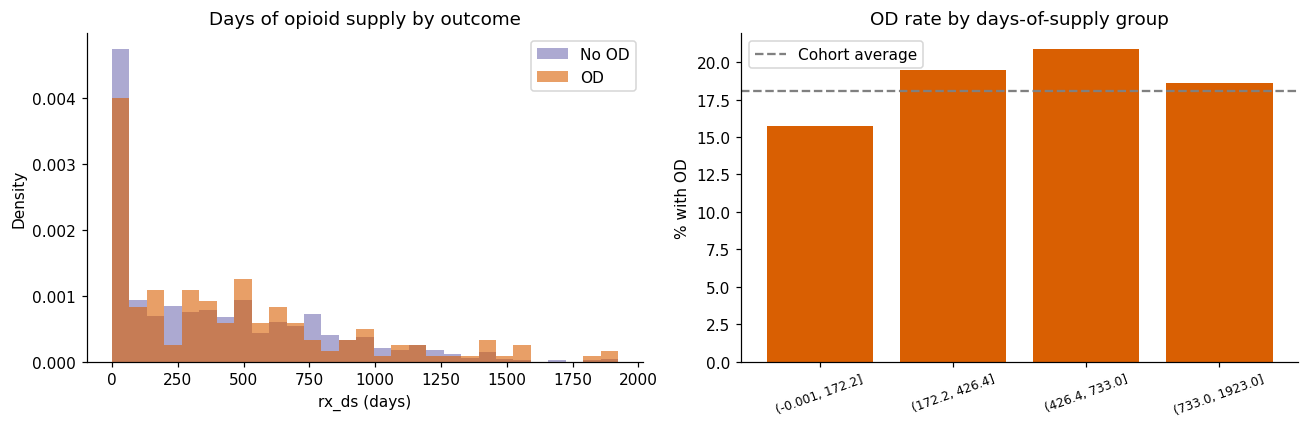

Share of patients with rx_ds > 0: 74.4%


,OD rate,patients
rx_ds,,
"(-0.001, 172.2]",15.8%,400
"(172.2, 426.4]",19.5%,200
"(426.4, 733.0]",20.9%,201
"(733.0, 1923.0]",18.6%,199


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(0, df[rx_col].max(), 30)
ax[0].hist(df.loc[df.OD == 0, rx_col], bins=bins, alpha=.6, color=C_NO, label="No OD", density=True)
ax[0].hist(df.loc[df.OD == 1, rx_col], bins=bins, alpha=.6, color=C_OD, label="OD", density=True)
ax[0].set(title="Days of opioid supply by outcome", xlabel="rx_ds (days)", ylabel="Density"); ax[0].legend()

q = pd.qcut(df[rx_col], 5, duplicates="drop")
rate = df.groupby(q, observed=True)["OD"].agg(["mean", "count"])
ax[1].bar(range(len(rate)), rate["mean"] * 100, color=C_OD)
ax[1].axhline(df.OD.mean() * 100, ls="--", c="grey", label="Cohort average")
ax[1].set_xticks(range(len(rate)), [str(i) for i in rate.index], rotation=20, fontsize=8)
ax[1].set(title="OD rate by days-of-supply group", ylabel="% with OD"); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"Share of patients with rx_ds > 0: {(df[rx_col] > 0).mean():.1%}")
display(rate.rename(columns={"mean": "OD rate", "count": "patients"}).style.format({"OD rate": "{:.1%}"}))

**What we see**
- About 3 in 4 patients have *some* opioid supply, so after binarizing, `rx_ds = 1` means "any supply", **not** "high supply"
- OD rate rises only slightly with days of supply here (around 16% to 21%), so binarizing loses little in *this* dataset. In real data, dose and duration are strong risk factors, so always check before throwing a continuous variable away

**Timing matters:** predictors and outcome come from the **same 2-year window**. So some prescriptions or diagnoses may have been recorded *after* OUD was recorded. This model therefore ranks existing records by risk (retrospective risk stratification). It does **not** predict who will develop OUD in the future. To predict the future you need predictors measured *before* a date and the outcome measured *after* it

We use a stratified 75% training / 25% test split for the first evaluation. Later, cross-validation checks calibration and compares models.

In [4]:
transformers = [
    ("bin_rx", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                         ("bin", Binarizer(threshold=0.0))]), [rx_col]),
    ("binary", SimpleImputer(strategy="most_frequent"), binary_cols),
]
preprocess = ColumnTransformer(transformers, remainder="drop", verbose_feature_names_out=False)

X = df[feature_cols].copy()
y = df["OD"].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training: {X_train.shape[0]} patients ({y_train.sum()} with OD)")
print(f"Test:     {X_test.shape[0]} patients ({y_test.sum()} with OD)")
print(f"OD prevalence in training set: {y_train.mean():.2%}")

Training: 750 patients (136 with OD)
Test:     250 patients (45 with OD)
OD prevalence in training set: 18.13%


## 3. Threshold policy and first evaluation

- **Receiver operating characteristic area under the curve (ROC AUC)**: if we pick one patient with OD and one without at random, how often does the model give the patient with OD the higher score? 0.5 = coin flip, 1.0 = perfect
- **Precision-recall area under the curve (PR AUC)**: focuses on identifying patients with OD when OD is the minority class. Here we report it using `average_precision_score`, which weights precision by increases in recall rather than using trapezoidal area. The no-skill baseline equals OD prevalence, about 18%

With only 45 patients with OD in the test set, estimates vary. We add a **95% bootstrap confidence interval** for ROC AUC and compare with the **raw `Low_inc` flag**, without fitting another model.

Metric reference: [scikit-learn: `average_precision_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html)

### 3.1. Step 1: set the alert threshold before we look at the test set

A model gives a score or ranking. To act on it, we need a **threshold**: flag the patient for review if their probability is at or above it. Using the software default of 0.5 would ignore everything we decided in the Responsible AI toolbox notebook. So we apply **the same policy rule** here:

1. Catch at least **60%** of recorded OUD cases (recall floor)
2. Flag no more than **300 patients per 1,000** (what the clinic can review)
3. Among thresholds that meet both, pick the one with the **highest precision** (fewest unnecessary reviews)
4. If none meets both, **say so**, and apply a fallback agreed in advance, never after seeing test results

A flag still means a **structured clinical review**, not a refusal of pain treatment.

**Why not reuse 0.22?** That number was chosen for a calibrated logistic regression. Naive Bayes produces probabilities on a different (less calibrated) scale, so the same number would not give the same workload. The *rule* travels between models; the *number* does not.

**Where do validation scores come from?** This notebook has no separate validation set, so we create one from the training data with 5-fold cross-validation: every training patient gets a score from a model that never saw them. The test set stays closed until section 3.2.

Primary rule NOT feasible: no threshold reaches 60% recall within 300 alerts per 1,000. Fallback: capacity is a hard limit, so catch as many cases as capacity allows

Selected threshold (frozen): 0.231
Validation: catches 80 of 136 recorded OUD cases (recall 58.8%, 95% CI 50% to 67%), precision 36.9%, 289 reviews per 1,000
To reach 60% recall, the clinic would need about 303 reviews per 1,000


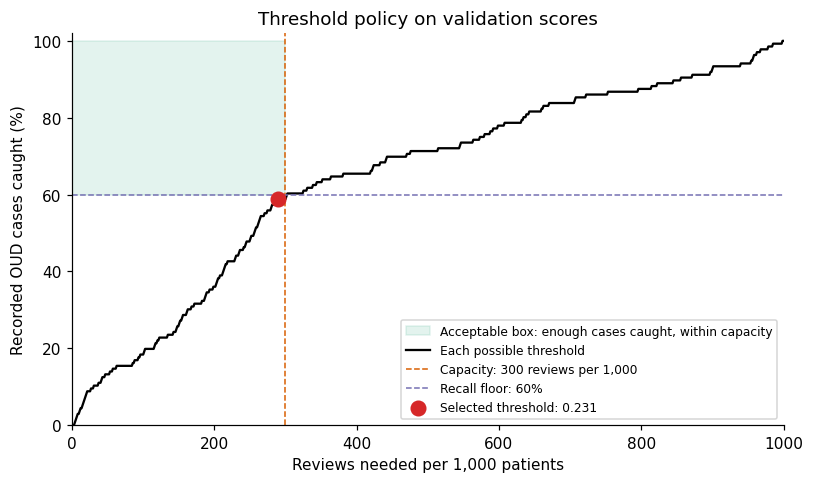

In [5]:
from utils import select_threshold, plot_threshold_policy, wilson_interval

MIN_RECALL = 0.60            # catch at least 60% of recorded OUD cases
MAX_ALERTS_PER_1000 = 300    # review capacity

nb_pipe = Pipeline([("prep", preprocess), ("nb", BernoulliNB(alpha=1.0, fit_prior=True))])

# Validation scores: each training patient is scored by a model trained on the other 4/5 of the training set
val_scores = cross_val_predict(nb_pipe, X_train, y_train,
                               cv=StratifiedKFold(5, shuffle=True, random_state=0),
                               method="predict_proba")[:, 1]

choice = select_threshold(y_train, val_scores, MIN_RECALL, MAX_ALERTS_PER_1000)
threshold = choice["threshold"]          # FROZEN from here on
sel, tbl_thr = choice["selected"], choice["table"]

rec_ci = wilson_interval(sel["TP"], sel["TP"] + sel["FN"])
needed = tbl_thr.loc[tbl_thr["recall"] >= MIN_RECALL, "alerts_per_1000"].min()

print(choice["rule"])
print(f"\nSelected threshold (frozen): {threshold:.3f}")
print(f"Validation: catches {int(sel['TP'])} of {int(sel['TP'] + sel['FN'])} recorded OUD cases "
      f"(recall {sel['recall']:.1%}, 95% CI {rec_ci[0]:.0%} to {rec_ci[1]:.0%}), "
      f"precision {sel['precision']:.1%}, {sel['alerts_per_1000']:.0f} reviews per 1,000")
print(f"To reach {MIN_RECALL:.0%} recall, the clinic would need about {needed:.0f} reviews per 1,000")

plot_threshold_policy(choice, MIN_RECALL, MAX_ALERTS_PER_1000)
plt.tight_layout(); plt.show()

**What happened?**
- **No threshold meets both conditions.** Within 300 reviews per 1,000, the best we can do is catch about **59%** of recorded OUD cases. Reaching 60% would need about **303 reviews per 1,000**. We miss the target by about one patient in the validation data
- **Rule 4 applies:** we do not quietly bend the rule. We report it, then use the fallback we declared in advance: **review capacity is a hard limit** (a clinic cannot review more patients than its staff can see), so we catch as many cases as capacity allows
- **Result:** threshold **0.231** (about 23%), frozen from here on. On validation it catches 80 of 136 recorded OUD cases (59%, 95% interval 50% to 67%) with 289 reviews per 1,000
- **For the clinical team, this is a real decision:** accept about 59% recall, add a little review capacity, or improve the model. Section 12 discusses the last option

### 3.2. Step 2: evaluate once on the test set
The threshold is now frozen. We train on all training patients and open the test set once.

--- Naive Bayes (all 20 features) ---
ROC AUC: 0.711  (95% CI 0.62 to 0.80)
PR AUC:  0.353  (no-skill baseline = 0.180)
At threshold 0.231 -> precision 0.418, recall 0.733

--- Baseline: Low_inc flag alone ---
ROC AUC: 0.745
PR AUC:  0.340  (no-skill baseline = 0.180)


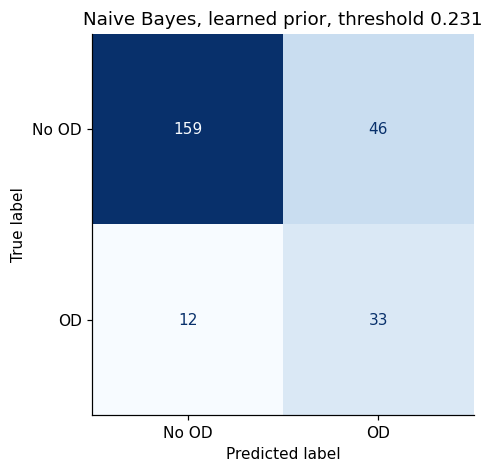

In [6]:
# Build the pipeline:
# alpha=1.0 applies Laplace smoothing so unseen/rare feature combinations never get probability exactly 0
# fit_prior=True learns the OD prior directly from the training data, about 18% in this cohort
nb_pipe = Pipeline([
    ("prep", preprocess),
    ("nb", BernoulliNB(alpha=1.0, fit_prior=True))
])

# Train the complete preprocessing + Naive Bayes pipeline
nb_pipe.fit(X_train, y_train)

# Predicted probability of OD for each patient
y_proba = nb_pipe.predict_proba(X_test)[:, 1]

# Use the threshold frozen in section 3.1 by the policy rule (not the 0.5 default)
y_pred = (y_proba >= threshold).astype(int)


# Bootstrap the test patients 2,000 times to estimate a 95% confidence interval for a metric
def boot_ci(y_true, score, metric, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    out = []

    for _ in range(n):
        # Sample patients with replacement, keeping the same sample size
        i = rng.integers(0, len(y_true), len(y_true))

        # ROC AUC requires both OD and No OD patients in the resampled data
        if 0 < y_true[i].sum() < len(i):
            out.append(metric(y_true[i], score[i]))

    # Keep the central 95% of the bootstrap results
    return np.percentile(out, [2.5, 97.5])


# Ranking metrics:
# ROC AUC asks how well the model ranks OD patients above No OD patients
# PR AUC focuses more directly on performance for the positive OD class
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

# 95% bootstrap confidence interval for ROC AUC
lo, hi = boot_ci(y_test, y_proba, roc_auc_score)

print("--- Naive Bayes (all 20 features) ---")
print(f"ROC AUC: {roc_auc:.3f}  (95% CI {lo:.2f} to {hi:.2f})")
print(f"PR AUC:  {pr_auc:.3f}  (no-skill baseline = {y_test.mean():.3f})")
print(
    f"At threshold {threshold:.3f} -> "
    f"precision {precision_score(y_test, y_pred):.3f}, "
    f"recall {recall_score(y_test, y_pred):.3f}"
)

# One-feature baseline:
# Use the binary Low_inc flag itself as a score, without fitting another model
# This asks whether that single yes/no variable ranks OD patients better than the full model
low_inc_score = X_test["Low_inc"]

roc_auc_lowinc = roc_auc_score(y_test, low_inc_score)
pr_auc_lowinc = average_precision_score(y_test, low_inc_score)

print("\n--- Baseline: Low_inc flag alone ---")
print(f"ROC AUC: {roc_auc_lowinc:.3f}")
print(f"PR AUC:  {pr_auc_lowinc:.3f}  (no-skill baseline = {y_test.mean():.3f})")


# Confusion matrix:
# Compare actual outcomes with predictions at our policy threshold
# It shows true negatives, false positives, false negatives and true positives
fig, ax = plt.subplots(figsize=(4.5, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=ax,
    cmap="Blues",
    colorbar=False,
    display_labels=["No OD", "OD"]
)

ax.set_title(f"Naive Bayes, learned prior, threshold {threshold:.3f}")
plt.show()

**Critical reading**

- The full 20-feature model does **not clearly outperform** the single `Low_inc` flag. `Low_inc` does slightly better on ROC AUC (0.745 vs 0.711), while the full model does slightly better on PR AUC (0.353 vs 0.340). The other 19 features add little clear value on this test split. We check this more reliably with cross-validation in section 9
- Both PR AUC scores exceed the **0.18 no-skill baseline**, so both contain useful signal. Much of the model's predictive power appears to come from income alone
- At our policy threshold of **0.231**, the model catches **33 of 45 patients with OD (73%, 95% interval 59% to 84%)** and misses 12. It flags 79 patients, including 46 false alarms, so **42% of flagged patients have OD**
- **Validation said 59% recall, the test says 73%.** With only 45 cases in the test set, a few patients more or less move recall a lot. This is why we report intervals, and why the 60% floor is a target, not a guarantee
- **Workload:** 79 flags out of 250 is about **316 per 1,000**, slightly above capacity on this test split, even though validation was within it. Same lesson: small samples wobble

## 4. The prior $P(OD=1)$: where it comes from and why it matters

By default (`fit_prior=True`) the prior is the class balance in the training data (18.1%). We can also **set it manually**, e.g. if the model will be deployed in a population with a different prevalence.

Here we use the external 5% prior from the previous exercise as a comparison.

⚠️ **Important:** the prior should match the population **where the model will be used**, not "the general population" by default. Our test set comes from the same cohort as the training data (18% prevalence), so a 5% prior is *deliberately wrong* for it. We use it to show the mechanics.

In [7]:
nb_model = nb_pipe.named_steps["nb"]
print(f"Learned prior P(OD=1): {np.exp(nb_model.class_log_prior_[1]):.4f}  (= training prevalence {y_train.mean():.4f})")

nb_external_prior = Pipeline([("prep", preprocess),
                              ("nb", BernoulliNB(alpha=1.0, fit_prior=False, class_prior=[0.95, 0.05]))])
nb_external_prior.fit(X_train, y_train)
ext_proba = nb_external_prior.predict_proba(X_test)[:, 1]
ext_pred = (ext_proba >= threshold).astype(int)

print("\n--- Ranking metrics (unchanged by the prior) ---")
print(f"ROC AUC  learned: {roc_auc_score(y_test, y_proba):.3f} | 5% prior: {roc_auc_score(y_test, ext_proba):.3f}")
print(f"PR AUC   learned: {average_precision_score(y_test, y_proba):.3f} | 5% prior: {average_precision_score(y_test, ext_proba):.3f}")

print(f"\n--- At threshold {threshold:.3f} (changed by the prior) ---")
for name, pred in [("Learned prior", y_pred), ("5% prior", ext_pred)]:
    tp = int(((pred == 1) & (y_test == 1)).sum()); fp = int(((pred == 1) & (y_test == 0)).sum())
    print(f"{name:14s}: flagged {pred.sum():3d} patients | true positives {tp:2d} | false positives {fp:2d} | "
          f"precision {precision_score(y_test, pred, zero_division=0):.3f} | recall {recall_score(y_test, pred):.3f}")

Learned prior P(OD=1): 0.1813  (= training prevalence 0.1813)

--- Ranking metrics (unchanged by the prior) ---
ROC AUC  learned: 0.711 | 5% prior: 0.711
PR AUC   learned: 0.353 | 5% prior: 0.353

--- At threshold 0.231 (changed by the prior) ---
Learned prior : flagged  79 patients | true positives 33 | false positives 46 | precision 0.418 | recall 0.733
5% prior      : flagged  22 patients | true positives  8 | false positives 14 | precision 0.364 | recall 0.178


### 4.1. What happened?

- **Ranking did not change**: changing only the prior adds the same constant to every patient's log-odds. Patient order, ROC AUC (0.711), and PR AUC (0.353) stay the same
- **Decisions changed at the same 0.231 threshold**: the learned prior flags 79 patients, with 33 true positives and 46 false positives (precision 0.418, recall 0.733). The 5% prior flags 22 patients, with 8 true positives and 14 false positives (precision 0.364, recall 0.178); it misses 37 of 45 OD cases
- **Probability levels changed**: the 5% prior lowers all scores despite the test cohort's 18% prevalence. A deployment prior must match the population, and calibration still needs checking

### 4.2. How a prior shift maps to a threshold shift

Changing only the prior shifts log-odds by a constant. A threshold $t$ under the new prior corresponds to a threshold $t^*$ under the learned prior:

$$\text{odds}(t^*) = \text{odds}(t) \times \frac{\text{odds}(\pi_{\text{learned}})}{\text{odds}(\pi_{\text{new}})}$$

The examples below verify this identity. They explain prior shift; our clinical comparison keeps the policy threshold (**0.231**) fixed for both models. If the deployment prior really changed, we would re-run the threshold policy of section 3.1 rather than reuse the old number.

In [8]:
odds = lambda p: p / (1 - p)
inv_odds = lambda o: o / (1 + o)
pi_learned, pi_new = y_train.mean(), 0.05

for t in [0.05, 0.10, threshold]:
    t_star = inv_odds(odds(t) * odds(pi_learned) / odds(pi_new))
    a = (ext_proba >= t).astype(int); b = (y_proba >= t_star - 1e-12).astype(int)
    print(f"5% prior @ {t:.2f}  ==  learned prior @ {t_star:.3f} | identical decisions: {np.array_equal(a, b)} | "
          f"precision {precision_score(y_test, a, zero_division=0):.2f}, recall {recall_score(y_test, a):.2f}")

5% prior @ 0.05  ==  learned prior @ 0.181 | identical decisions: True | precision 0.37, recall 0.76
5% prior @ 0.10  ==  learned prior @ 0.319 | identical decisions: True | precision 0.39, recall 0.58
5% prior @ 0.23  ==  learned prior @ 0.558 | identical decisions: True | precision 0.36, recall 0.18


### 4.3. How much does the prior move one patient's risk?
The curve below shows the same patient's post-test probability as we change only the prior. This is the clinical idea of **pre-test probability**: the same findings mean very different things in a general practice vs a pain clinic vs an addiction service.

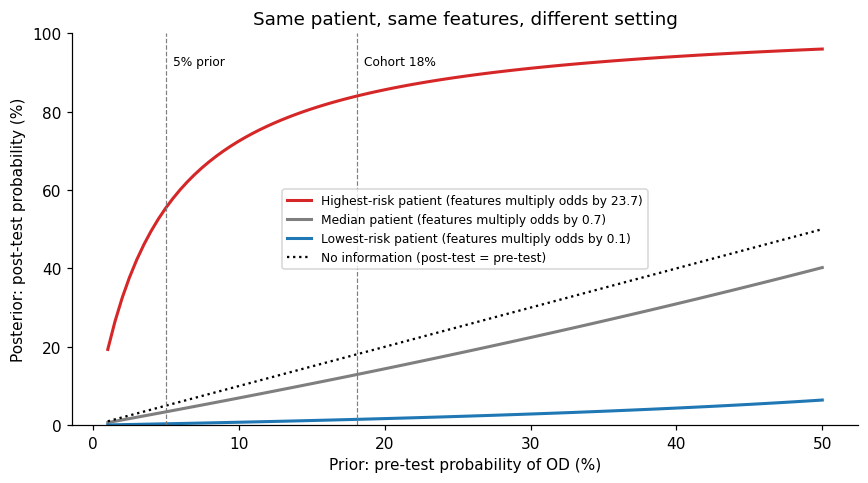

In [9]:
Xt = nb_pipe.named_steps["prep"].transform(X_test)
llr = (nb_model.predict_joint_log_proba(Xt)[:, 1] - nb_model.predict_joint_log_proba(Xt)[:, 0]
       - (nb_model.class_log_prior_[1] - nb_model.class_log_prior_[0]))   # evidence from features only

priors = np.linspace(0.01, 0.5, 100)
picks = {"Highest-risk patient": np.argmax(llr), "Median patient": np.argsort(llr)[len(llr)//2],
         "Lowest-risk patient": np.argmin(llr)}
fig, ax = plt.subplots(figsize=(8, 4.5))
for (label, i), c in zip(picks.items(), ["#d62728", "#7f7f7f", "#1f77b4"]):
    post = inv_odds(odds(priors) * np.exp(llr[i]))
    ax.plot(priors * 100, post * 100, c=c, lw=2, label=f"{label} (features multiply odds by {np.exp(llr[i]):.1f})")
ax.plot(priors * 100, priors * 100, "k:", label="No information (post-test = pre-test)")
for p, txt in [(5, "5% prior"), (18.1, "Cohort 18%")]:
    ax.axvline(p, ls="--", c="grey", lw=.8); ax.text(p + .5, 92, txt, fontsize=8)
ax.set(xlabel="Prior: pre-test probability of OD (%)", ylabel="Posterior: post-test probability (%)",
       title="Same patient, same features, different setting", ylim=(0, 100)); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Inside the model: what it learned (global view)

The likelihoods $P(x=1 \mid OD)$ do **not** depend on the prior, so both models share this table. We show **all** features, including those pointing *away* from OD, which the top-10 view hides.

How to read it, in clinical language:
- `P(x=1|OD=1)`: sensitivity of the flag, e.g. 61% of patients with OD are low income
- `P(x=1|OD=0)`: 1 − specificity, e.g. 24% of patients without OD are low income
- `LR+`: how much a **present** flag multiplies the odds of OD
- `LR-`: how much an **absent** flag multiplies the odds of OD (BernoulliNB uses this too)
- `log_OR = ln(LR+) − ln(LR−)`: the gap between "flag present" and "flag absent". Useful for ranking, but it inflates common features: `rx_ds` has LR+ of only 1.09 yet ranks 3rd because its absence is mildly protective

⚠️ Read LR+ in the right direction. "Low income is 2.6× more common among patients with OD" is **not** "low-income patients are 2.6× more likely to develop OD". Swapping the two is the classic *inverse probability fallacy*.

In [10]:
feat_names = np.array([n.replace("binary__", "").replace("bin_rx__", "") for n in
                       nb_pipe.named_steps["prep"].get_feature_names_out()])
p1 = np.exp(nb_model.feature_log_prob_[1]); p0 = np.exp(nb_model.feature_log_prob_[0])

tbl = pd.DataFrame({
    "feature": feat_names,
    "P(x=1|OD=1)": p1, "P(x=1|OD=0)": p0,
    "LR+": p1 / p0, "LR-": (1 - p1) / (1 - p0),
}).assign(log_OR=lambda d: np.log(d["LR+"]) - np.log(d["LR-"])).sort_values("log_OR", ascending=False)

display(tbl.style.hide(axis="index").format(precision=3)
        .background_gradient(subset=["log_OR"], cmap="RdBu_r", vmin=-1.7, vmax=1.7))

feature,P(x=1|OD=1),P(x=1|OD=0),LR+,LR-,log_OR
Low_inc,0.609,0.237,2.568,0.513,1.611
V,0.094,0.057,1.658,0.960,0.546
rx_ds,0.790,0.727,1.086,0.771,0.343
F,0.565,0.521,1.085,0.908,0.178
E,0.609,0.571,1.065,0.913,0.154
SURG,0.442,0.407,1.085,0.942,0.142
J,0.522,0.502,1.040,0.960,0.081
N,0.471,0.451,1.044,0.964,0.079
A,0.362,0.352,1.029,0.984,0.044
K,0.529,0.528,1.003,0.997,0.006


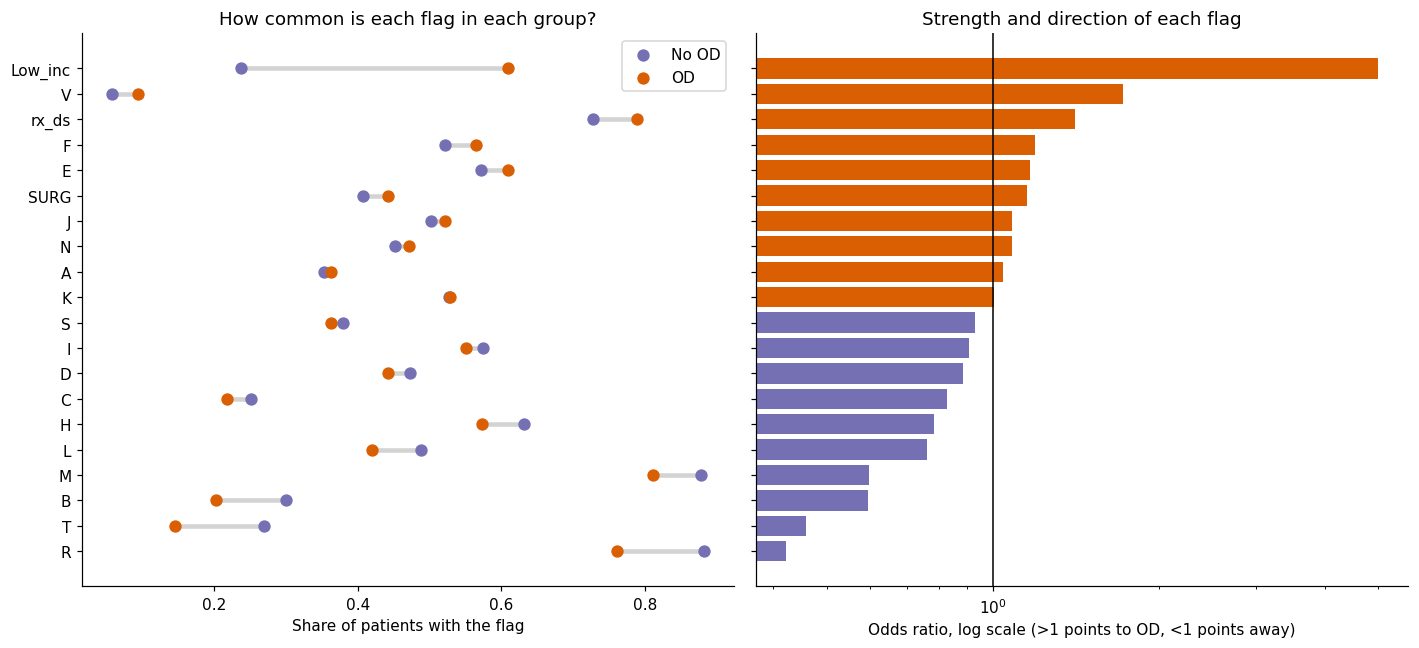

In [11]:
t = tbl.sort_values("log_OR")
fig, ax = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
yy = np.arange(len(t))
ax[0].hlines(yy, t["P(x=1|OD=0)"], t["P(x=1|OD=1)"], color="lightgrey", lw=3)
ax[0].scatter(t["P(x=1|OD=0)"], yy, color=C_NO, s=50, label="No OD", zorder=3)
ax[0].scatter(t["P(x=1|OD=1)"], yy, color=C_OD, s=50, label="OD", zorder=3)
ax[0].set(yticks=yy, yticklabels=t["feature"], xlabel="Share of patients with the flag",
          title="How common is each flag in each group?"); ax[0].legend()
colors = [C_OD if v > 0 else C_NO for v in t["log_OR"]]
ax[1].barh(yy, np.exp(t["log_OR"]), color=colors); ax[1].axvline(1, c="k", lw=1)
ax[1].set_xscale("log"); ax[1].set(xlabel="Odds ratio, log scale (>1 points to OD, <1 points away)",
                                   title="Strength and direction of each flag")
plt.tight_layout(); plt.show()

**What the chart shows**
- One feature dominates: **low income** (odds ratio ≈ 5). Everything else is close to 1
- Several flags point **away** from OD: `R` (symptoms), `T` (injury/poisoning), `M` (musculoskeletal), `B`. These are as informative as most "positive" flags but were missing from the top-10 table
- Clinically surprising directions (e.g. `T`, which includes poisonings, pointing away from OD) are a cue to question the data. Here the data is synthetic, so odd patterns may come from how it was generated. With real data, ask about coding practices and how the cohort was built

## 6. How sure are we? Laplace smoothing is a Bayesian prior

`BernoulliNB(alpha=1)` does not use raw percentages. It adds 1 "imaginary" patient with and 1 without each flag:

$$P(x=1 \mid OD) = \frac{\text{count} + 1}{n_{OD} + 2}$$

This is exactly the **posterior mean of a Beta(1, 1) prior** (a flat prior: "any percentage is equally plausible before seeing data") updated with the observed counts. So every likelihood in the table is itself a Bayesian estimate, and it has a full posterior distribution we can use to express uncertainty.

Example: `V` is present in only a handful of patients with OD. How confident should we be in its LR+ of 1.7?

Training counts | V: 12/136 OD patients vs 34/614 non-OD
                | Low_inc: 83/136 OD patients vs 145/614 non-OD


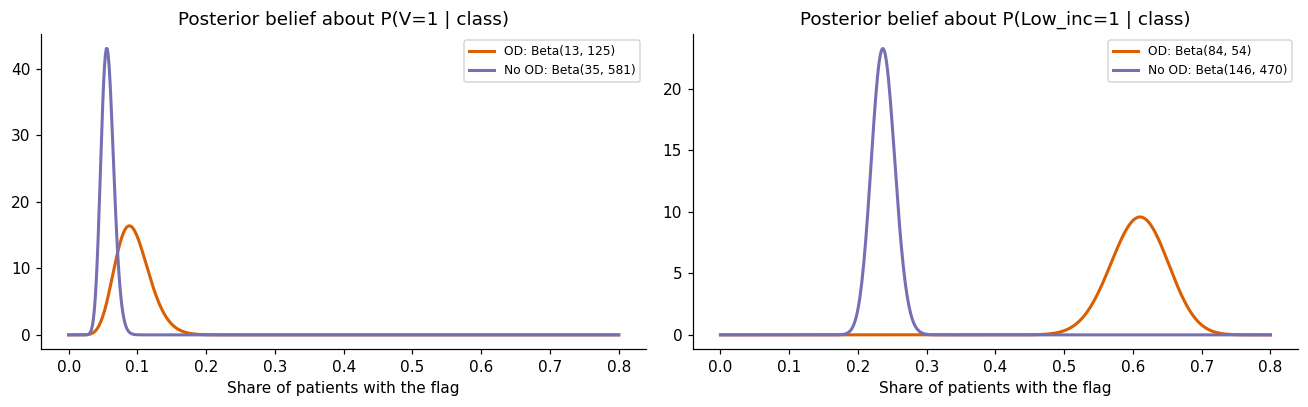

In [12]:
from scipy import stats
nb_c = nb_model.class_count_; fc = nb_model.feature_count_
j_v, j_li = list(feat_names).index("V"), list(feat_names).index("Low_inc")
print(f"Training counts | V: {fc[1, j_v]:.0f}/{nb_c[1]:.0f} OD patients vs {fc[0, j_v]:.0f}/{nb_c[0]:.0f} non-OD")
print(f"                | Low_inc: {fc[1, j_li]:.0f}/{nb_c[1]:.0f} OD patients vs {fc[0, j_li]:.0f}/{nb_c[0]:.0f} non-OD")

xs = np.linspace(0, 0.8, 600)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for a, j, name in [(ax[0], j_v, "V"), (ax[1], j_li, "Low_inc")]:
    for c, col, lab in [(1, C_OD, "OD"), (0, C_NO, "No OD")]:
        k, n = fc[c, j], nb_c[c]
        a.plot(xs, stats.beta(k + 1, n - k + 1).pdf(xs), color=col, lw=2, label=f"{lab}: Beta({k+1:.0f}, {n-k+1:.0f})")
    a.set(title=f"Posterior belief about P({name}=1 | class)", xlabel="Share of patients with the flag"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

The curves are the model's *belief* about each percentage. Where the two curves overlap, the data cannot tell the groups apart with confidence. Next we turn these beliefs into a **95% credible interval for every LR+** by simulation (draw both percentages from their Beta curves, divide, repeat 20,000 times).

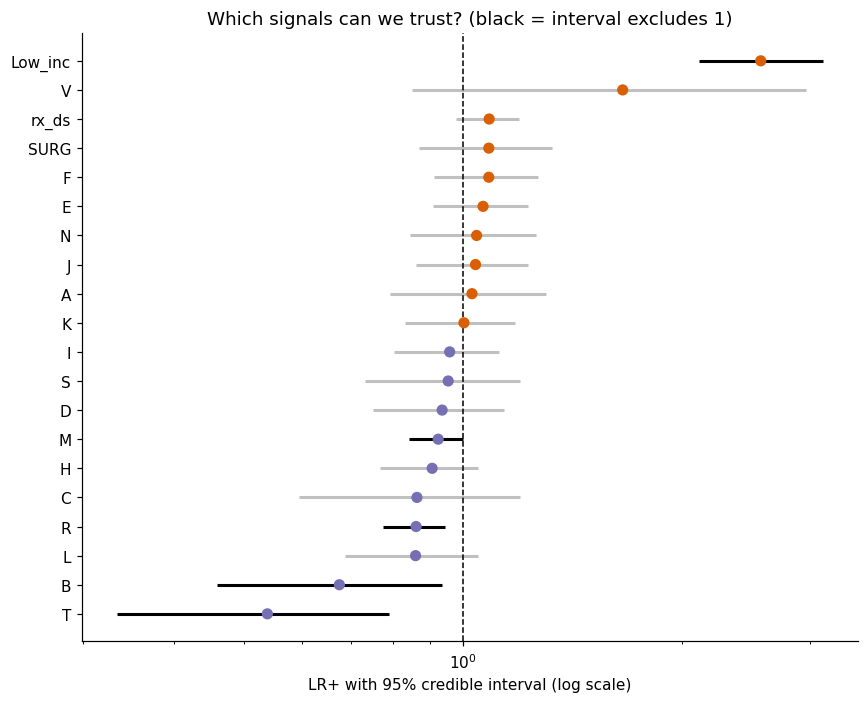

feature,LR+,low,high,P(LR+ > 1)
Low_inc,2.57,2.11,3.13,1.00
V,1.66,0.85,2.96,0.93
rx_ds,1.09,0.98,1.19,0.94
SURG,1.08,0.87,1.32,0.77
F,1.08,0.91,1.27,0.83
E,1.07,0.91,1.23,0.80
N,1.04,0.85,1.26,0.66
J,1.04,0.86,1.23,0.67
A,1.03,0.79,1.30,0.59
K,1.00,0.83,1.18,0.52


In [13]:
rng = np.random.default_rng(0); S = 20_000
rows = []
for j, name in enumerate(feat_names):
    d1 = rng.beta(fc[1, j] + 1, nb_c[1] - fc[1, j] + 1, S)
    d0 = rng.beta(fc[0, j] + 1, nb_c[0] - fc[0, j] + 1, S)
    lr = d1 / d0
    rows.append({"feature": name, "LR+": p1[j] / p0[j], "low": np.percentile(lr, 2.5),
                 "high": np.percentile(lr, 97.5), "P(LR+ > 1)": (lr > 1).mean()})
cred = pd.DataFrame(rows).sort_values("LR+")

fig, ax = plt.subplots(figsize=(8, 6.5))
yy = np.arange(len(cred))
sure = (cred["low"] > 1) | (cred["high"] < 1)
ax.hlines(yy, cred["low"], cred["high"], color=np.where(sure, "k", "silver"), lw=2)
ax.scatter(cred["LR+"], yy, color=np.where(cred["LR+"] > 1, C_OD, C_NO), zorder=3, s=40)
ax.axvline(1, c="k", ls="--", lw=1); ax.set_xscale("log")
ax.set(yticks=yy, yticklabels=cred["feature"], xlabel="LR+ with 95% credible interval (log scale)",
       title="Which signals can we trust? (black = interval excludes 1)")
plt.tight_layout(); plt.show()
display(cred.sort_values("LR+", ascending=False).style.hide(axis="index").format(precision=2))

**Reading it for clinicians**
- Only a few intervals clearly exclude 1 (black lines). Those are the signals the data supports
- `V` has a wide interval: it rests on about a dozen patients with OD. Saying "V makes OD 1.7× more likely" overstates what we know. A fair statement is "we can't rule out that V carries no information"
- `P(LR+ > 1)` is the posterior probability that the flag points toward OD. A Bayesian answer to "how sure are we about the direction?"
- With 20 features tested at once, a couple will look "significant" by chance. Treat single weak signals as hypotheses, not findings

## 7. One patient: from pre-test to post-test probability (local view)

We follow one test patient step by step: start at the prior, then let each feature multiply the odds. This is the same reasoning as a Fagan nomogram: **pre-test probability × likelihood ratios → post-test probability**.

We also check that our hand calculation matches `sklearn` exactly. Nothing is hidden.

In [14]:
test_i = 20             # change to explore other patients
model = nb_pipe         # try nb_external_prior to see the 5% version
m = model.named_steps["nb"]
x = model.named_steps["prep"].transform(X_test)[test_i].astype(int)

lp1, lp0 = m.feature_log_prob_[1], m.feature_log_prob_[0]
contrib = np.where(x == 1, lp1 - lp0, np.log1p(-np.exp(lp1)) - np.log1p(-np.exp(lp0)))  # ln LR per feature
base = m.class_log_prior_[1] - m.class_log_prior_[0]                                       # ln prior odds
total = base + contrib.sum()

p_manual = 1 / (1 + np.exp(-total))
p_sklearn = model.predict_proba(X_test.iloc[[test_i]])[0, 1]
print(f"Patient {test_i} | true label OD={y_test.iloc[test_i]}")
print(f"Pre-test probability (prior): {1/(1+np.exp(-base)):.1%}")
print(f"Features multiply the odds by: {np.exp(contrib.sum()):.2f}")
print(f"Post-test probability: manual {p_manual:.4f} | sklearn {p_sklearn:.4f} | match: {np.isclose(p_manual, p_sklearn)}")

local = pd.DataFrame({"feature": feat_names, "value": x, "LR (×odds)": np.exp(contrib),
                      "log contribution": contrib}).sort_values("log contribution", key=abs, ascending=False)
display(local.head(10).style.hide(axis="index").format(precision=3))

Patient 20 | true label OD=0
Pre-test probability (prior): 18.1%
Features multiply the odds by: 2.79
Post-test probability: manual 0.3816 | sklearn 0.3816 | match: True


feature,value,LR (×odds),log contribution
Low_inc,1,2.568,0.943
T,0,1.170,0.157
L,1,0.860,-0.151
R,1,0.862,-0.149
H,0,1.160,0.149
C,1,0.864,-0.146
B,0,1.139,0.130
rx_ds,1,1.086,0.083
SURG,1,1.085,0.081
F,1,1.085,0.081


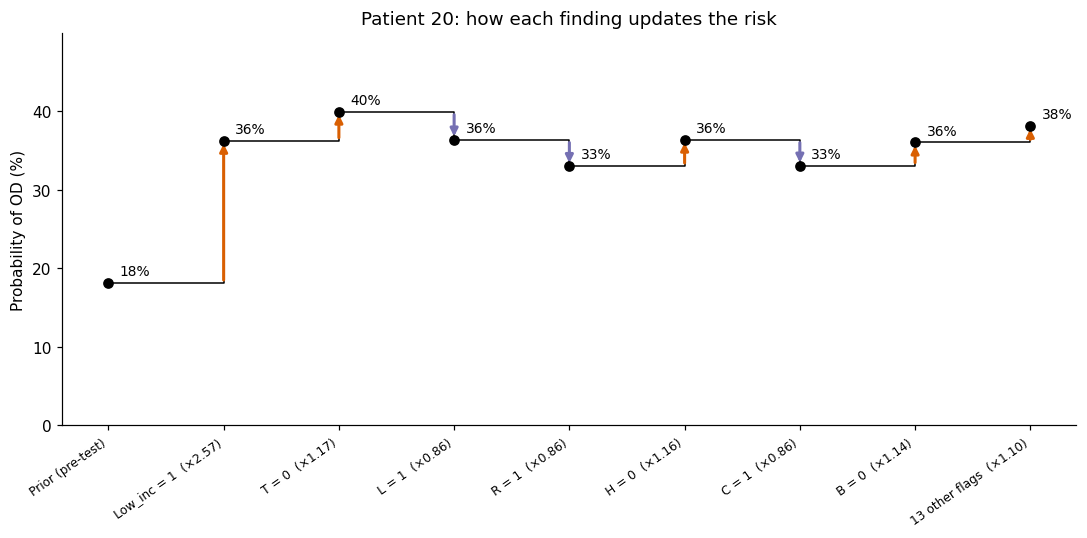

In [15]:
# Step-by-step update: biggest contributors first, the rest grouped
top_k = 7
order = local.index[:top_k]
steps_lbl = ["Prior (pre-test)"]; steps_lo = [base]
for j in order:
    steps_lo.append(steps_lo[-1] + contrib[j])
    steps_lbl.append(f"{feat_names[j]} = {x[j]}  (×{np.exp(contrib[j]):.2f})")
rest = contrib.sum() - contrib[order].sum()
steps_lo.append(steps_lo[-1] + rest); steps_lbl.append(f"{len(contrib) - top_k} other flags  (×{np.exp(rest):.2f})")
probs = 100 / (1 + np.exp(-np.array(steps_lo)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.step(range(len(probs)), probs, where="post", c="k", lw=1)
for i in range(1, len(probs)):
    up = probs[i] > probs[i-1]
    ax.annotate("", xy=(i, probs[i]), xytext=(i, probs[i-1]),
                arrowprops=dict(arrowstyle="-|>", color=C_OD if up else C_NO, lw=2))
ax.scatter(range(len(probs)), probs, c="k", zorder=3)
for i, p in enumerate(probs): ax.text(i + .1, p + 1, f"{p:.0f}%", fontsize=9)
ax.set_xticks(range(len(probs)), steps_lbl, rotation=35, ha="right", fontsize=8)
ax.set(ylabel="Probability of OD (%)", title=f"Patient {test_i}: how each finding updates the risk",
       ylim=(0, max(probs) * 1.25))
plt.tight_layout(); plt.show()

**How to say it to a clinician**
- "Before looking at this patient, 18 in 100 similar patients have OD. Their findings together multiply the odds by about 3, so their risk is now about 38 in 100: roughly double the average, but still more likely *not* to have OD"
- With the 5% prior the same patient scores about 13%. That is still **2.6× the baseline risk**. A low absolute probability can still be a meaningful *relative* increase, so "the model predicts No OD" is not the same as "the model says this patient is fine"
- Notice that **absent** flags also move the risk (for patient 20, `T = 0` and `H = 0` push it up). This is specific to BernoulliNB and often surprises people

## 8. Is the "naive" assumption a problem here?

If two features are correlated within a class, Naive Bayes counts the same evidence twice and becomes **overconfident**: probabilities get pushed toward 0 or 1. Ranking can still be fine, but the numbers stop meaning "X in 100 patients".

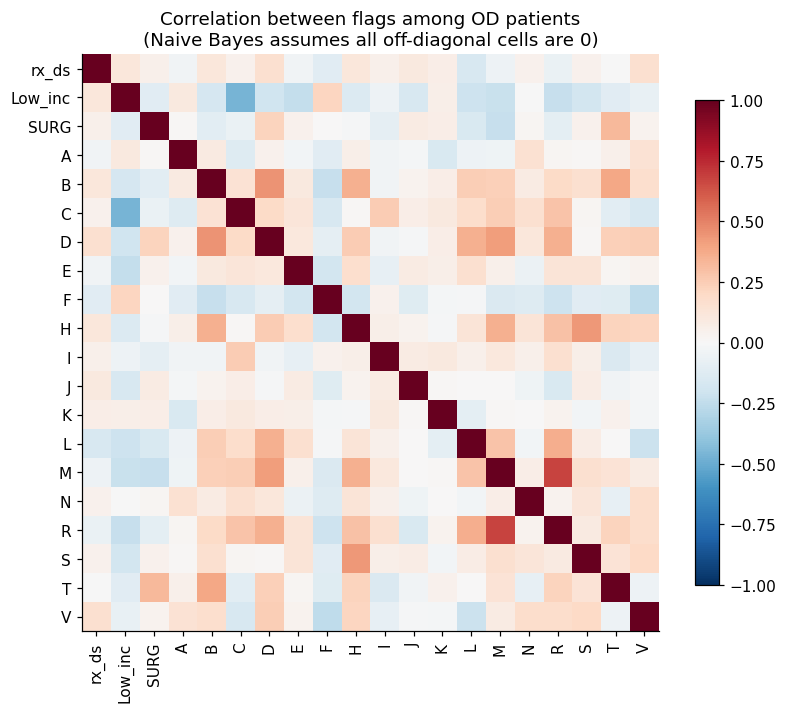

Strongest pairs:
 M        R    0.68
Low_inc  C    0.47
B        D    0.45
H        S    0.43
D        M    0.42


In [16]:
Xtr_bin = pd.DataFrame(nb_pipe.named_steps["prep"].transform(X_train), columns=feat_names)
corr = Xtr_bin[y_train.values == 1].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feat_names)), feat_names, rotation=90); ax.set_yticks(range(len(feat_names)), feat_names)
ax.set_title("Correlation between flags among OD patients\n(Naive Bayes assumes all off-diagonal cells are 0)")
plt.colorbar(im, ax=ax, shrink=.8); plt.tight_layout(); plt.show()

pairs = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool)).stack()
print("Strongest pairs:\n", pairs.abs().sort_values(ascending=False).head(5).round(2).to_string())

`M` and `R` are strongly correlated among patients with OD (r ≈ 0.68), and both point *away* from OD. Naive Bayes multiplies both LRs as if they were independent pieces of evidence, which double counts.

### 8.1. Calibration: do the probabilities mean what they say?
We use 5-fold cross-validated predictions on all 1,000 patients (more stable than 250 test patients). A well-calibrated model sits on the diagonal: among patients scored "30%", about 30% should have OD.

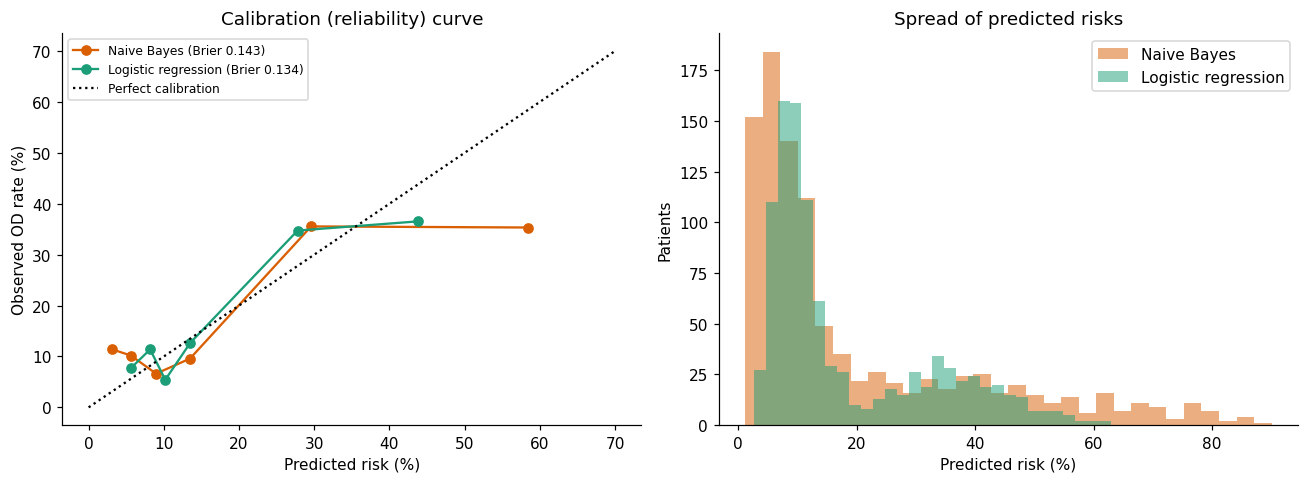

In [17]:
cv5 = StratifiedKFold(5, shuffle=True, random_state=0)
lr_pipe = Pipeline([("prep", preprocess), ("lr", LogisticRegression(max_iter=1000))])
cv_nb = cross_val_predict(nb_pipe, X, y, cv=cv5, method="predict_proba")[:, 1]
cv_lr = cross_val_predict(lr_pipe, X, y, cv=cv5, method="predict_proba")[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for s, name, col in [(cv_nb, "Naive Bayes", C_OD), (cv_lr, "Logistic regression", "#1b9e77")]:
    fy, fx = calibration_curve(y, s, n_bins=6, strategy="quantile")
    ax[0].plot(fx * 100, fy * 100, "o-", color=col, label=f"{name} (Brier {brier_score_loss(y, s):.3f})")
    ax[1].hist(s * 100, bins=30, alpha=.5, color=col, label=name)
ax[0].plot([0, 70], [0, 70], "k:", label="Perfect calibration")
ax[0].set(xlabel="Predicted risk (%)", ylabel="Observed OD rate (%)", title="Calibration (reliability) curve"); ax[0].legend(fontsize=8)
ax[1].set(xlabel="Predicted risk (%)", ylabel="Patients", title="Spread of predicted risks"); ax[1].legend()
plt.tight_layout(); plt.show()

**What to look for**
- Naive Bayes spreads predictions more widely than logistic regression (right panel), the typical overconfidence from double counting
- Overconfident at both ends: in its highest-risk group it predicts about 58% but only about 35% have OD; in its lowest-risk group it predicts about 3% but about 11% have OD
- If the model's probabilities will be shown to clinicians as "this patient has a 55% risk", calibration matters as much as AUC. Fixes: recalibrate (`CalibratedClassifierCV`), drop redundant features, or use logistic regression

## 9. Comparison with logistic regression and a decision tree

One train/test split with 45 positives is noisy, so we use **10 × repeated 5-fold cross-validation** (50 fits per model). Here the one-feature comparison **fits a separate Bernoulli Naive Bayes model using `Low_inc` only**, unlike the raw flag baseline in section 3.

,ROC AUC,ROC AUC sd,PR AUC,PR AUC sd,Brier (lower=better)
"NB, all features",0.692,0.049,0.354,0.048,0.145
"NB, Low_inc only",0.701,0.030,0.306,0.028,0.132
Logistic regression,0.705,0.038,0.359,0.050,0.136
Decision tree (depth 3),0.711,0.040,0.325,0.040,0.137


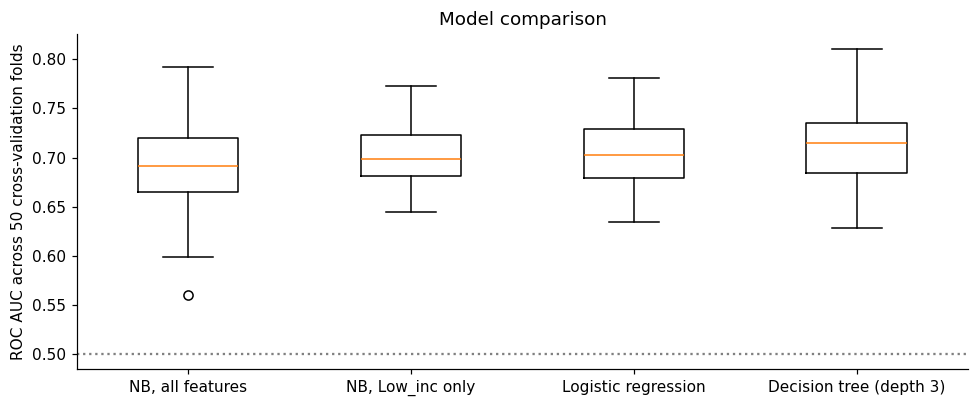

In [18]:
models = {
    "NB, all features": nb_pipe,
    "NB, Low_inc only": Pipeline([("sel", ColumnTransformer([("li", "passthrough", ["Low_inc"])])),
                                  ("nb", BernoulliNB())]),
    "Logistic regression": lr_pipe,
    "Decision tree (depth 3)": Pipeline([("prep", preprocess),
                                         ("dt", DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=0))]),
}
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
res = {n: cross_validate(m, X, y, cv=rcv, scoring=["roc_auc", "average_precision", "neg_brier_score"])
       for n, m in models.items()}

summary = pd.DataFrame({n: {"ROC AUC": r["test_roc_auc"].mean(), "ROC AUC sd": r["test_roc_auc"].std(),
                            "PR AUC": r["test_average_precision"].mean(),
                            "PR AUC sd": r["test_average_precision"].std(),
                            "Brier (lower=better)": -r["test_neg_brier_score"].mean()} for n, r in res.items()}).T
display(summary.style.format(precision=3))

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.boxplot([r["test_roc_auc"] for r in res.values()])
ax.set_xticks(range(1, len(res) + 1), list(res))
ax.axhline(.5, c="grey", ls=":"); ax.set(ylabel="ROC AUC across 50 cross-validation folds", title="Model comparison")
plt.tight_layout(); plt.show()

**Takeaways**

- The full Naive Bayes model has mean ROC AUC **0.692** and PR AUC **0.354**. The fitted `Low_inc` model has **0.701** and **0.306**, respectively. The full model gains PR AUC but loses a little ROC AUC; it shows no clear overall improvement. The extra features add little clear value beyond income here
- Across all four models, mean ROC AUC ranges from **0.692 to 0.711**, with fold standard deviations of **0.030 to 0.049**. Mean PR AUC ranges from **0.306 to 0.359**, with standard deviations of **0.028 to 0.050**. ROC AUC differences are smaller than fold variability; PR AUC differences are comparable to it. These repeated folds are not independent, so their spread is not a confidence interval or a formal test of model differences
- Logistic regression has a lower Brier score here, consistent with better calibration in section 8.1. Ranking and calibration answer separate questions
- Naive Bayes remains useful: it is fast, works with small samples, and its estimates can be traced to counts in 2×2 tables

## 10. What does our threshold mean in practice?

Our threshold (**0.231**, about 23%) was set in section 3.1 with the same policy rule as the Responsible AI toolbox notebook. We keep it fixed: a patient is flagged for **structured clinical review** when their predicted OD probability is at least 23%. A flag is decision support, never an automatic refusal or taper of pain treatment.

Here we check workload, missed cases and clinical utility of that rule across the whole cohort.

### 10.1. Natural frequencies: what happens to 1,000 patients?

We use the same 5-fold cross-validated predictions as the calibration check, so each patient's score comes from a model trained on other patients. These cohort-wide counts differ from the 250-patient test results in section 3.

In [19]:
def per_1000(y_true, score, t):
    y_true, flag = np.asarray(y_true), np.asarray(score) >= t
    n = len(y_true); tp = (flag & (y_true == 1)).sum(); fp = (flag & (y_true == 0)).sum()
    fn = ((~flag) & (y_true == 1)).sum()
    return {"threshold": f"{t:.0%}", "flagged": 1000 * flag.sum() / n, "OD cases caught": 1000 * tp / n,
            "OD cases missed": 1000 * fn / n, "false alarms": 1000 * fp / n,
            "flags per true case": flag.sum() / tp if tp else np.nan}

nf = pd.DataFrame([per_1000(y, cv_nb, threshold)])
print(f"Out of 1,000 patients, about {1000 * y.mean():.0f} have OD. Naive Bayes, cross-validated:")
display(nf.style.hide(axis="index").format(precision=0, subset=["flagged", "OD cases caught", "OD cases missed", "false alarms"])
        .format(precision=1, subset=["flags per true case"]))

Out of 1,000 patients, about 181 have OD. Naive Bayes, cross-validated:


threshold,flagged,OD cases caught,OD cases missed,false alarms,flags per true case
23%,292,112,69,180,2.6


### 10.2. Clinical utility check at our threshold

The decision curve compares the model with acting on everyone or no one. **Net benefit** counts true positives and subtracts false positives weighted by the relative harm implied by the threshold:

$$\text{Net benefit} = \frac{TP}{n} - \frac{FP}{n} \times \frac{t}{1-t}$$

At our threshold, a model adds value if its net benefit exceeds both reference policies. The rest of the curve is context; we do not use it to pick a new threshold.

Reference: [Vickers & Elkin (2006), decision curve analysis](https://pmc.ncbi.nlm.nih.gov/articles/PMC2577036/)

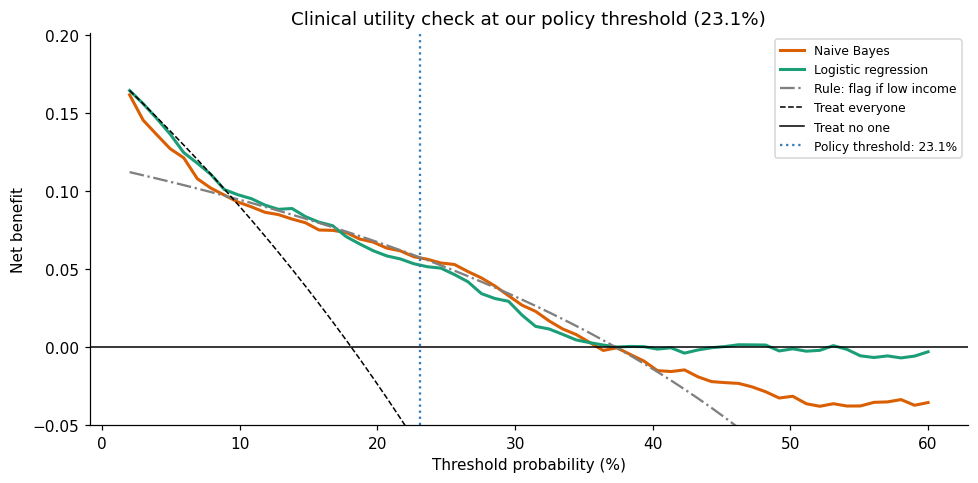

,Net benefit at 23%
Naive Bayes,0.058
Logistic regression,0.053
Rule: flag if low income,0.057
Treat everyone,-0.065
Treat no one,0.000


In [20]:
ts = np.linspace(0.02, 0.6, 60)
def net_benefit(y_true, s, t):
    y_true = np.asarray(y_true); f = np.asarray(s) >= t; n = len(y_true)
    return ((f & (y_true == 1)).sum() - (f & (y_true == 0)).sum() * t / (1 - t)) / n

prev = y.mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ts * 100, [net_benefit(y, cv_nb, t) for t in ts], c=C_OD, lw=2, label="Naive Bayes")
ax.plot(ts * 100, [net_benefit(y, cv_lr, t) for t in ts], c="#1b9e77", lw=2, label="Logistic regression")
ax.plot(ts * 100, [net_benefit(y, X["Low_inc"], t) for t in ts], c="grey", lw=1.5, ls="-.", label="Rule: flag if low income")
ax.plot(ts * 100, prev - (1 - prev) * ts / (1 - ts), "k--", lw=1, label="Treat everyone")
ax.axhline(0, c="k", lw=1, label="Treat no one")
ax.axvline(threshold * 100, c="#377eb8", ls=":", lw=1.5, label=f"Policy threshold: {threshold:.1%}")
ax.set(ylim=(-0.05, prev + .02), xlabel="Threshold probability (%)", ylabel="Net benefit",
       title=f"Clinical utility check at our policy threshold ({threshold:.1%})"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

utility = pd.Series({
    "Naive Bayes": net_benefit(y, cv_nb, threshold),
    "Logistic regression": net_benefit(y, cv_lr, threshold),
    "Rule: flag if low income": net_benefit(y, X["Low_inc"], threshold),
    "Treat everyone": prev - (1 - prev) * threshold / (1 - threshold),
    "Treat no one": 0.0,
}, name=f"Net benefit at {threshold:.0%}")
display(utility.to_frame().style.format(precision=3))

**Reading it at our policy threshold (about 23%)**

- Among 1,000 patients, Naive Bayes flags **292**, catches **112 of 181 OD cases**, misses **69**, and raises **180 false alarms**. That is about **2.6 reviews per OD case found**
- **Capacity check:** 292 reviews per 1,000 is within the 300 limit across the whole cohort
- Net benefit is **0.058** for Naive Bayes and **0.053** for logistic regression, above treating everyone (**-0.065**) or no one (**0.000**). The model is better than either simple policy at this threshold
- The `Low_inc` rule reaches **0.057**, so the full model adds no clear clinical utility beyond that simple rule. This does not mean acting on income is appropriate; section 11 examines its consequences
- These are synthetic cohort results. A real deployment would need validation in the intended population and workflow

## 11. Equity: what if the main signal is income?

If low income drives most of the score, the model will mostly flag low-income patients. Let's check who gets flagged at our policy threshold.

In [21]:
t = threshold
g = pd.DataFrame({"Low_inc": X["Low_inc"].map({1: "Low income", 0: "Not low income"}), "y": y, "flag": cv_nb >= t})
rows = []
for grp, d in g.groupby("Low_inc"):
    rows.append({"group": grp, "patients": len(d), "OD rate": d.y.mean(), "flagged": d.flag.mean(),
                 "recall (OD cases caught)": (d.flag & (d.y == 1)).sum() / max((d.y == 1).sum(), 1),
                 "precision (flags that are OD)": (d.flag & (d.y == 1)).sum() / max(d.flag.sum(), 1)})
out = pd.DataFrame(rows).set_index("group")
display(out.style.format({"patients": "{:.0f}", "OD rate": "{:.0%}", "flagged": "{:.0%}",
                          "recall (OD cases caught)": "{:.0%}", "precision (flags that are OD)": "{:.0%}"}))

,patients,OD rate,flagged,recall (OD cases caught),precision (flags that are OD)
group,,,,,
Low income,311,37%,86%,92%,40%
Not low income,689,9%,3%,8%,21%


**What the table shows:** at our threshold (about 23%), the model flags **268 of 311 low-income patients (86%)**, versus **24 of 689 other patients (3%)**. It catches **107 of 116 OD cases (92%)** in the low-income group, but only **5 of 65 (8%)** in the other group. Precision is **40%** and **21%**, respectively.

**Discussion points for clinicians and policymakers**

- **Association does not prove causation**: income marks risk in this dataset, but these results do not explain why
- **Who carries the burden of false alarms?** Restrictive actions could harm low-income patients most; supportive actions such as follow-up attach a different consequence to the same flag
- **Who is missed?** Most patients with OD outside the low-income group are missed, creating a blind spot
- **Same input, different policy**: the ethics depend on the action attached to the score


## 12. How could we improve this model?

1. **Use better clinical features**: consider dose, duration, previous overdose, mental-health history, and concurrent sedative use. Check their timing and clinical relevance; the current non-income features add little clear predictive value here
2. **Reduce redundant or weak features**: correlated features can make Naive Bayes double-count evidence. Remove or combine features only when cross-validation supports better performance on unseen patients
3. **Improve calibration**: logistic regression performs similarly and is better calibrated here. Naive Bayes can also be recalibrated; this improves probability estimates rather than ranking

Improve features and calibration when changing algorithms adds little value

## 13. Summary

| Concept | What we saw |
|---|---|
| Prior | Learn about 18% from training. An external 5% prior changes probabilities, while ROC AUC and PR AUC stay unchanged |
| Likelihoods | Per-feature sensitivity and 1 minus specificity give likelihood ratios |
| Smoothing | Laplace smoothing corresponds to a Beta(1, 1) prior on each feature probability |
| Naive assumption | Correlated features can double-count evidence and produce overconfident probabilities |
| Performance | ROC AUC and PR AUC show useful signal, but the 20-feature model adds little clear value beyond income |
| Calibration | Check whether predicted probabilities match observed rates; ranking alone does not answer this |
| Decisions | Set the threshold with the course policy rule (recall floor, capacity, precision) on validation data, freeze it, then evaluate once. Here the rule was not feasible and the pre-declared capacity fallback gave 0.231 |
| Ethics | Audit who is flagged and missed, and attach an action that supports patients |

## 14. Questions for students

1. A clinic where 40% of patients have OD wants to use this model. What should change, and what should not? (Hint: prior vs likelihoods)
2. Pick a test patient with a post-test probability around 15%. Explain their result to a general practitioner in three sentences, without the words "log-odds" or "likelihood"
3. Remove `Low_inc` and retrain. What happens to **both ROC AUC and PR AUC**? What does that tell you about the other 19 features?
4. Replace the binarized `rx_ds` with 4 bins (`KBinsDiscretizer`) and `CategoricalNB`. Does the model improve?
5. Set `alpha=10` and then `alpha=0.01`. Which features change most, and why? Link your answer to the Beta prior
6. Would you use this model to trigger a **structured clinical review** at our policy threshold (**0.231**)? Use case detection, false alarms, review capacity, calibration, clinical utility, and equity to justify your answer